# Import

In [1]:
from parcels import (
        FieldSet,
        JITParticle,
        ScipyParticle,
        ParticleSet,
        AdvectionRK4,
        AdvectionRK4_3D,
        StatusCode,
)
import parcels

import datetime as dt
from datetime import datetime, timedelta

import dask

import numpy as np
from numpy.random import uniform, randint

from pathlib import Path
import geopandas as gpd
import pandas as pd

import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors
import cmocean

import xarray as xr
from glob import glob
import cartopy
import cartopy.crs as ccrs
from time import time
import warnings
import shapely
import itertools

warnings.simplefilter("ignore")

# Set Parameters

In [25]:
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Fucus_BSH_20210101-20210129_dt60min_N43600_seed123.zarr")
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2021/TEST_Nested_20210101-20210108_dt60min_N500_seed123.zarr")
# zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2023/Fucus_BSH_20230701-20231230_dt60min_N235440_seed123.zarr")
zarr_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/output/Trajectories/2022/Fucus_BSH_20220101-20220625_dt60min_N453440_seed123.zarr")
ds_trajectories = xr.open_zarr(zarr_path)#.compute()
ds_trajectories.nbytes/1e9

96.205479136

In [26]:
try: ds_trajectories = ds_trajectories.rename(dict(CellID="cell_ID"))
except: ds_trajectories

In [27]:
release_area_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/Fucus_location_shp")
gdf_release_area = gpd.read_file(Path(release_area_path, "REDLIST_SIS_Macrophytes.geojson"))
gdf_release_area = gdf_release_area.loc[(gdf_release_area.F_vesiculo != 0).values, ["geometry", "CELLCODE"]]

subbasins_path = Path("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/HELCOM_subbasins_2022_level2")
gdf_subbasins_area = gpd.read_file(Path(subbasins_path, "HELCOM_subbasins_2022_level2.shp"))
gdf_subbasins_area = gdf_subbasins_area.to_crs(crs=ccrs.Geodetic()).rename(dict(level_2="subbasin"), axis=1)

In [28]:
release_centroid = gpd.GeoDataFrame(gdf_release_area.CELLCODE, geometry=gdf_release_area.geometry.centroid)
gdf_release_area = gpd.sjoin_nearest(
        left_df=release_centroid, 
        right_df=gdf_subbasins_area, 
        how="left", 
        rsuffix="basin_",
)[["CELLCODE", "subbasin", "geometry"]]

In [29]:
# # release_dates = ds_trajectories.time.where("obs"==0, ds_trajectories.time.isel(obs=0))
# release_dates = ds_trajectories.time.isel(obs=0)
# ds_trajectories = ds_trajectories.assign(release_date=release_dates)

In [30]:
def calc_dist(ds):
        ds = ds[["lon", "lat"]]
        dist = 111e3 * (
                ((ds - ds.isel(obs=0, drop=True)) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).rename("dist")

In [ ]:
ds_trajectories = ds_trajectories.assign(dict(
        distance=calc_dist(ds_trajectories),
        subbasin=("trajectory", gdf_release_area.loc[list_cell_ID].subbasin.values),
        # cell_code=("trajectory", cell_codes),
        # age_sec_obs=("obs", age_sec_obs),
        # cell_ID=("trajectory", list_cell_ID),
        # trajectory_ID=("trajectory", trajectories),
))

In [8]:
try: list_cell_ID = ds_trajectories.cell_ID.isel(obs=0).values.astype(int)
except: ""

In [37]:
try: ds_trajectories.lat.isel(trajectory=0).compute()
except: ds_trajectories = ds_trajectories.isel(obs=slice(2112))

In [38]:
last_valid_obs = ds_trajectories.obs.where(ds_trajectories.lon.notnull()).max('obs').astype(int).compute()
last_step = ds_trajectories.isel(obs=last_valid_obs).compute()

ds_trajectories = ds_trajectories.where(ds_trajectories.isel(obs=0).lon.compute() != last_step.lon, drop=True)

In [ ]:
lon_min, lon_max = (5,32)
lat_min, lat_max = (53,66)
central_longitude = np.mean((lon_min, lon_max))
central_latitude = np.mean((lat_min, lat_max))
lon_range = lon_max-lon_min
lat_range = lat_max-lat_min

# Coastbuffer
Make coast buffer for check if near coast or in open water

In [43]:
administrative_borders = gpd.read_file("/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/_ags_Administrative_boundaries/Administrative_boundaries.shp")
sh_border = administrative_borders.set_index("NAME").loc[["Schleswig-Holstein"]].to_crs(crs=ccrs.Geodetic())

In [44]:
# https://github.com/Yichabod/natural_disaster_pred/blob/master/cropping_coordinates.py

earth_radius = 6271.0
degrees_to_radians = np.pi / 180.0
radians_to_degrees = 180.0 / np.pi

def dlat_to_dkm(dlat):
        return dlat * earth_radius * degrees_to_radians
def dlon_to_dkm(latitude, dlon):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dlon / r * degrees_to_radians

def dkm_to_dlat(dkm):
        return dkm / earth_radius * degrees_to_radians
def dkm_to_dlon(latitude, dkm):
        r = earth_radius * np.cos(np.multiply(latitude, degrees_to_radians))
        return dkm / r * degrees_to_radians

<Axes: >

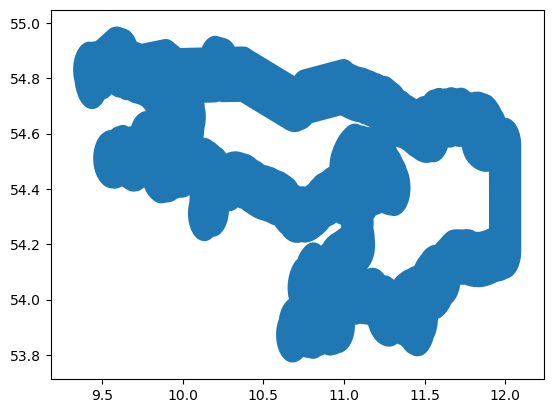

In [45]:
gdf_baltic = gdf_subbasins_area.clip(mask=(0,0,12,55)).cx[:11.5, :54.6].dissolve()
coast_region_radius_deg = .1
gdf_baltic_buffed = gdf_baltic.buffer(coast_region_radius_deg)
gdf_baltic_unbuffed = gdf_baltic.buffer(-coast_region_radius_deg)
gdf_baltic_coast = gdf_baltic.boundary.buffer(coast_region_radius_deg)
gdf_baltic_coast.plot()

<Axes: >

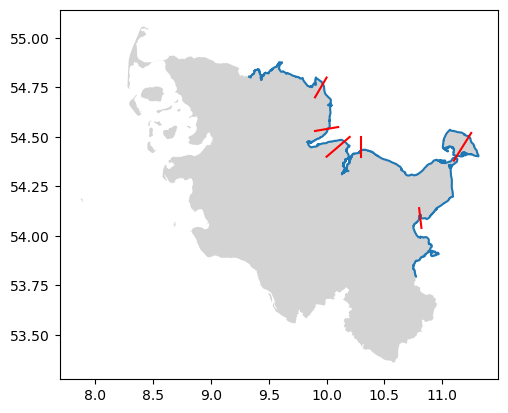

In [97]:
sh_coast = (
        sh_border
        .boundary
        .clip(gdf_baltic_buffed)
        .explode()
)
fig, ax = plt.subplots()
sh_coast.plot(ax=ax)
ax.plot([10,10.2], [54.4,54.5], c="r")
ax.plot([9.9,10], [54.7,54.8], c="r")
ax.plot([9.9,10.1], [54.53,54.55], c="r")
ax.plot([10.3,10.3], [54.4,54.5], c="r")
ax.plot([11.1,11.25], [54.38,54.52], c="r")
ax.plot([10.8,10.82], [54.14,54.04], c="r")
sh_border.plot(ax=ax, color="lightgrey")


In [279]:
# list(
np.append(shapely.get_parts(split(sh_coast.geometry[1], splitlines)), sh_coast.geometry[0])

array([<LINESTRING (9.322 54.806, 9.325 54.806, 9.327 54.806, 9.328 54.806, 9.329 5...>,
       <LINESTRING (9.967 54.767, 9.968 54.766, 9.969 54.765, 9.97 54.765, 9.971 54...>,
       <LINESTRING (10.012 54.541, 10.012 54.541, 10.01 54.538, 10.01 54.538, 10.00...>,
       <LINESTRING (10.153 54.477, 10.156 54.476, 10.159 54.475, 10.159 54.475, 10....>,
       <LINESTRING (10.3 54.432, 10.301 54.432, 10.301 54.432, 10.302 54.432, 10.30...>,
       <LINESTRING (11.122 54.392, 11.122 54.392, 11.123 54.392, 11.123 54.392, 11....>,
       <LINESTRING (10.809 54.096, 10.809 54.096, 10.809 54.096, 10.808 54.097, 10....>,
       <LINESTRING (11.25 54.412, 11.25 54.412, 11.25 54.412, 11.249 54.412, 11.249...>],
      dtype=object)

In [307]:
from shapely.ops import split
splitlines = shapely.MultiLineString([
                ((10.8,54.14),(10.82,54.04)),
                ((11.11,54.38),(11.25,54.52)),
                ((10.3,54.4), (10.3,54.5)),
                ((9.9,54.53),(10.1,54.55)),
                ((9.9,54.7),(10,54.8)),
                ((10,54.4),(10.2,54.5)),
])
sh_coast_split = gpd.GeoDataFrame(
        dict(
                names=["Flensburger Foerde", "Schleimuendung", "Eckernfoerde","Kieler Foerde","Kieler Bucht","Mecklenburger Bucht","Luebecker Bucht", "Fehmarn"], 
                geometry=np.append(shapely.get_parts(split(sh_coast.geometry[1], splitlines)), sh_coast.geometry[0]),
        ),
        # crs=ccrs.Geodetic()
).explode().reset_index(drop=True).set_index("names")

In [111]:
def cut(line, distance, lines):
     # Cuts a line in several segments at a distance from its starting point
     if distance <= 0.0 or distance >= line.length:
         return [shapely.LineString(line)]
     coords = list(line.coords)
     for i, p in enumerate(coords):
         pd = line.project(shapely.Point(p))
         if pd == distance:
             return [
                 shapely.LineString(coords[:i+1]),
                 shapely.LineString(coords[i:])
                 ]
         if pd > distance:
             cp = line.interpolate(distance)
             lines.append(shapely.LineString(coords[:i] + [(cp.x, cp.y)]))
             line = shapely.LineString([(cp.x, cp.y)] + coords[i:])
             if line.length > distance:
                 cut(line, distance, lines)
             else:
                 lines.append(shapely.LineString([(cp.x, cp.y)] + coords[i:]))
             return lines

<Axes: >

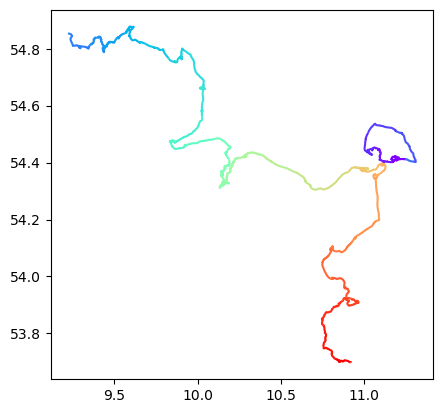

In [16]:
sh_coast_10km = gpd.GeoDataFrame(
        geometry=np.concatenate(
                [cut(line, .2, list()) for line in sh_coast]
        ),
        crs=ccrs.Geodetic(),
)
sh_coast_10km.plot(cmap="rainbow")

In [17]:
sh_release_areas = gdf_release_area.loc[
        np.transpose(
                [
                        gdf_release_area.intersects(geom)
                        for geom 
                        in sh_coast_10km.buffer(.2).geometry.explode()
                ]
        ).sum(axis=1) > 0
]

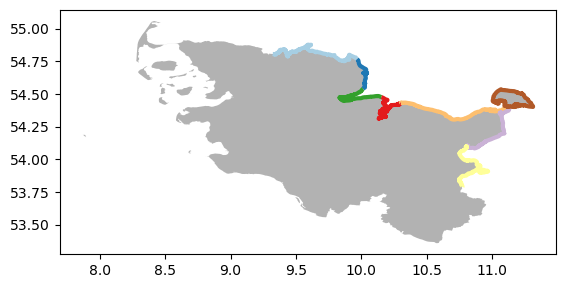

In [308]:
fig, ax = plt.subplots()
sh_border.to_crs(crs=ccrs.Geodetic()).plot(ax=ax, alpha=.6, color="gray")
sh_coast_split.plot(cmap="Paired", ax=ax, lw=3)
# sh_release_areas.plot(ax=ax)
plt.show()

In [100]:
ds_SH = ds_trajectories.isel(
        trajectory=ds_trajectories.cell_ID.isin(sh_release_areas.index).compute().any(dim="obs")
)

In [ ]:
ds_SH_0 = list(ds_SH[["lon", "lat", "z"]].groupby("z"))[0][1].drop("z").unstack()

In [140]:
from xhistogram.xarray import histogram as xhist


In [141]:
def calc_hist_0(ds, lon_bins, lat_bins, dims=["trajectory"]):
        return xhist(
                ds.lon, ds.lat,
                bins=[lon_bins, lat_bins],
                dim=dims,
        ).rename(dict(lon_bin="lon",lat_bin="lat"))

In [218]:
# sinnvolles vmin vmax, 
n_bins = 100
ds_s = calc_hist_0(
        ds_SH_0,
        np.linspace(ds_SH.lon.min(), ds_SH.lon.max(), n_bins),
        np.linspace(ds_SH.lat.min(), ds_SH.lat.max(), n_bins),
        dims=[
                "trajectory", 
                # "obs",
        ],
).compute()

In [219]:
n_bins = 120
ds_plot_0 = ds_SH[["lon", "lat", "z"]].groupby("z").apply(
        lambda ds: 
        calc_hist_0(
                ds.unstack(),
                np.linspace(ds_SH.lon.min(), ds_SH.lon.max(), n_bins),
                np.linspace(ds_SH.lat.min(), ds_SH.lat.max(), n_bins),
                dims=["trajectory"],
        )
).compute()

In [150]:
def calc_hist_1(ds, lon_bins, lat_bins, dims=["trajectory"], weights=None):
        return (
                xhist(
                        ds.lon, ds.lat,
                        bins=[lon_bins, lat_bins],
                        dim=dims,
                        weights=weights,
                ).rename(dict(lon_bin="lon",lat_bin="lat")) 
                / calc_hist_0(ds, lon_bins, lat_bins, dims)
        )

In [24]:
# sinnvolles vmin vmax, 
# sinnvolle cmap (1D, dichte visualisiert)
ds_plot_1 = ds_trajectories.groupby("subbasin").apply(
        lambda ds: 
        calc_hist_1(
                ds,
                np.linspace(lon_min, lon_max, 120),
                np.linspace(lat_min, lat_max, 120),
                dims=["trajectory", "obs"],
                weights=ds.obs,
        )
).compute()

In [149]:
subbasins_simple = gdf_subbasins_area.set_index("level_2").geometry.buffer(0.2).buffer(-0.2).exterior

# Maps

## Heatmap

In [220]:
ds_plot_0_sum = ds_plot_0.sum(dim="obs")

In [221]:
ds_plot_0_sum_log = np.log10(ds_plot_0_sum)

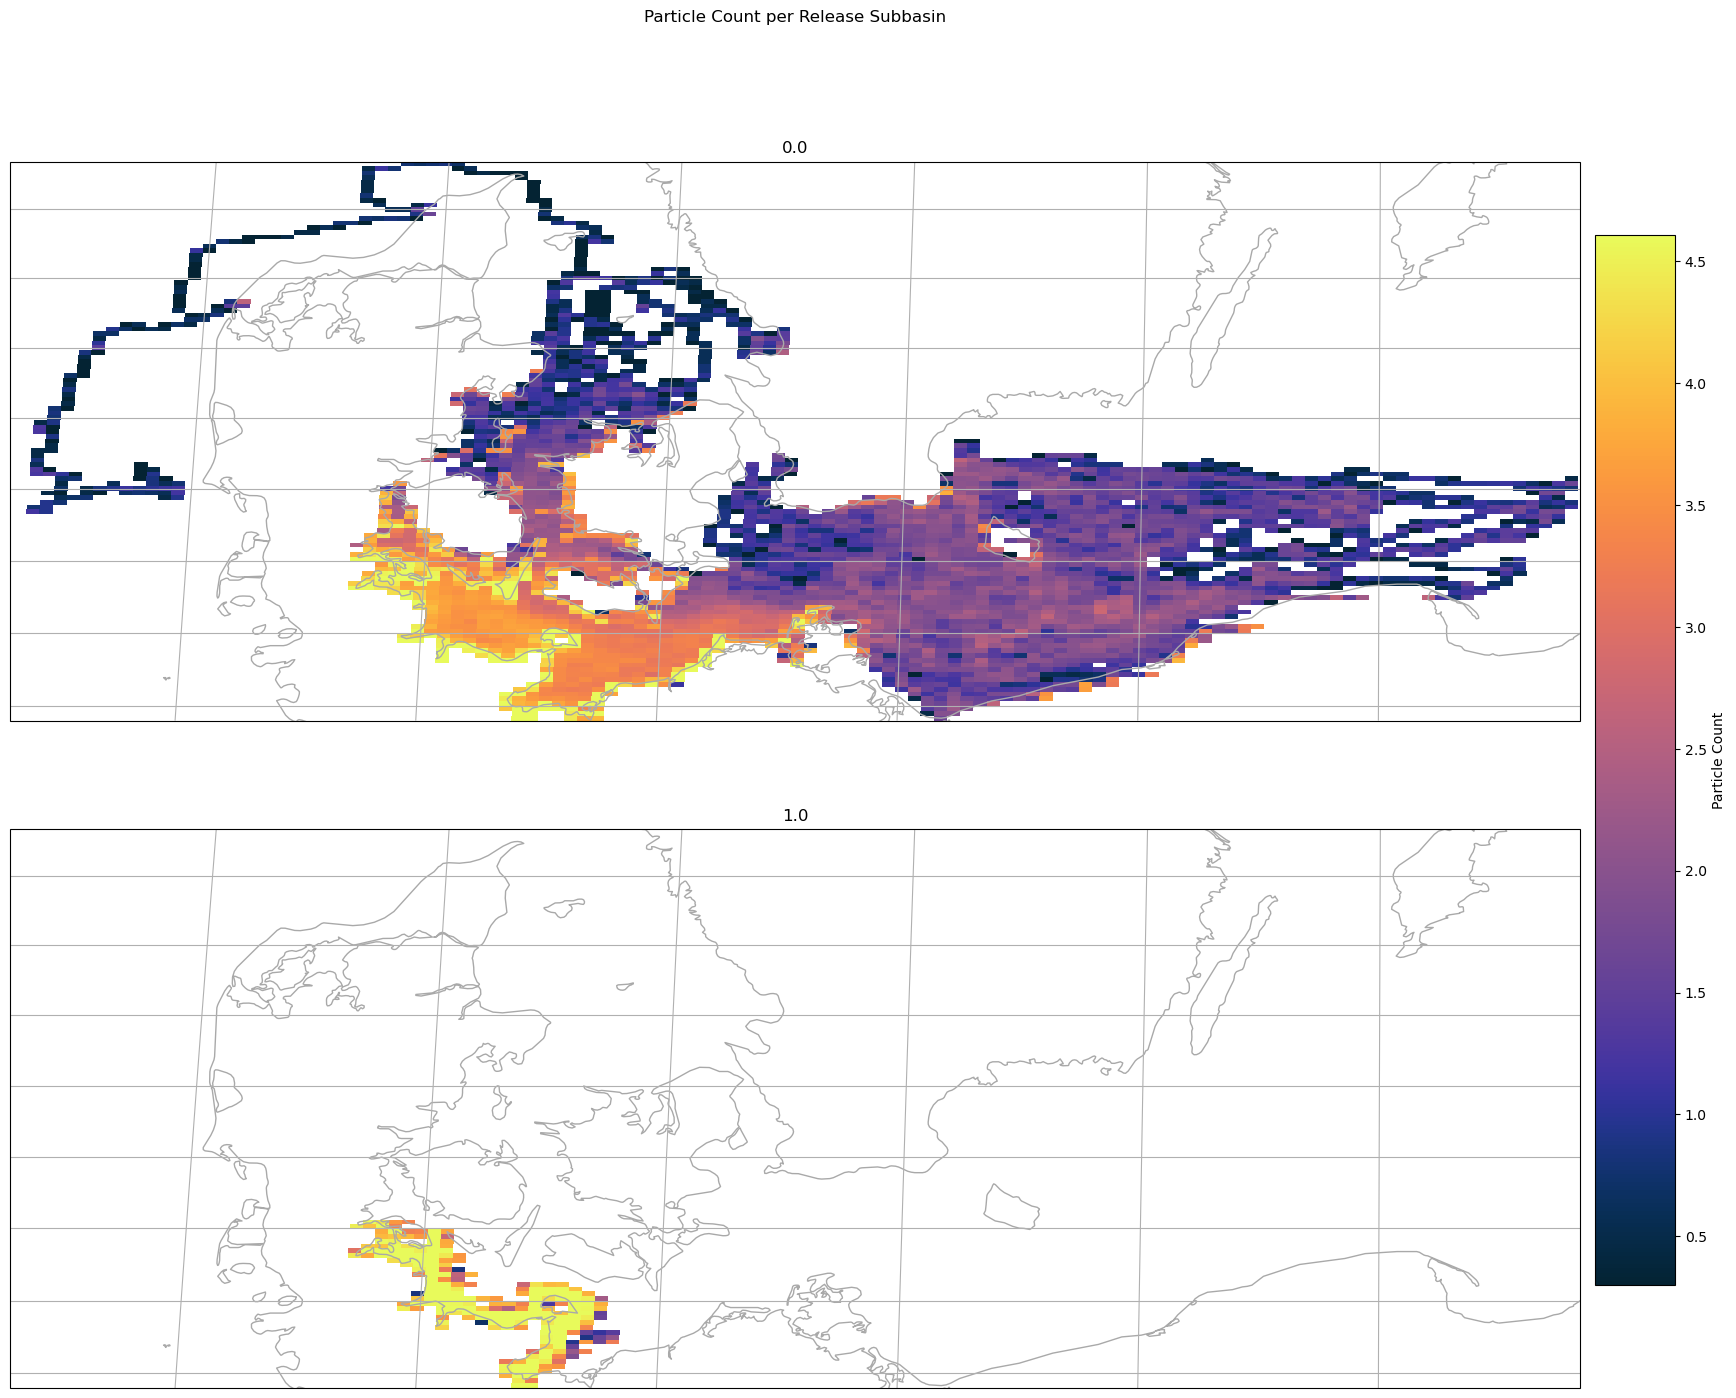

In [224]:
vmin, vmax = list(ds_plot_0_sum_log.where(ds_plot_0_sum_log.notnull() & ~np.isinf(ds_plot_0_sum_log)).quantile([0.05, 0.95]))

fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=2, ncols=1, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Particle Count per Release Subbasin", y=1)
for ax, z in zip(axes.flatten(), ds_plot_0_sum_log.z.values):
        im = ds_plot_0_sum_log.sel(z=z).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                vmin=vmin, vmax=vmax, 
                cmap=cmocean.cm.thermal,
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(z)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((ds_SH.lon.min(), ds_SH.lon.max(), ds_SH.lat.min(), ds_SH.lat.max()))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Particle Count")
fig.tight_layout()
plt.show()

## Agemap

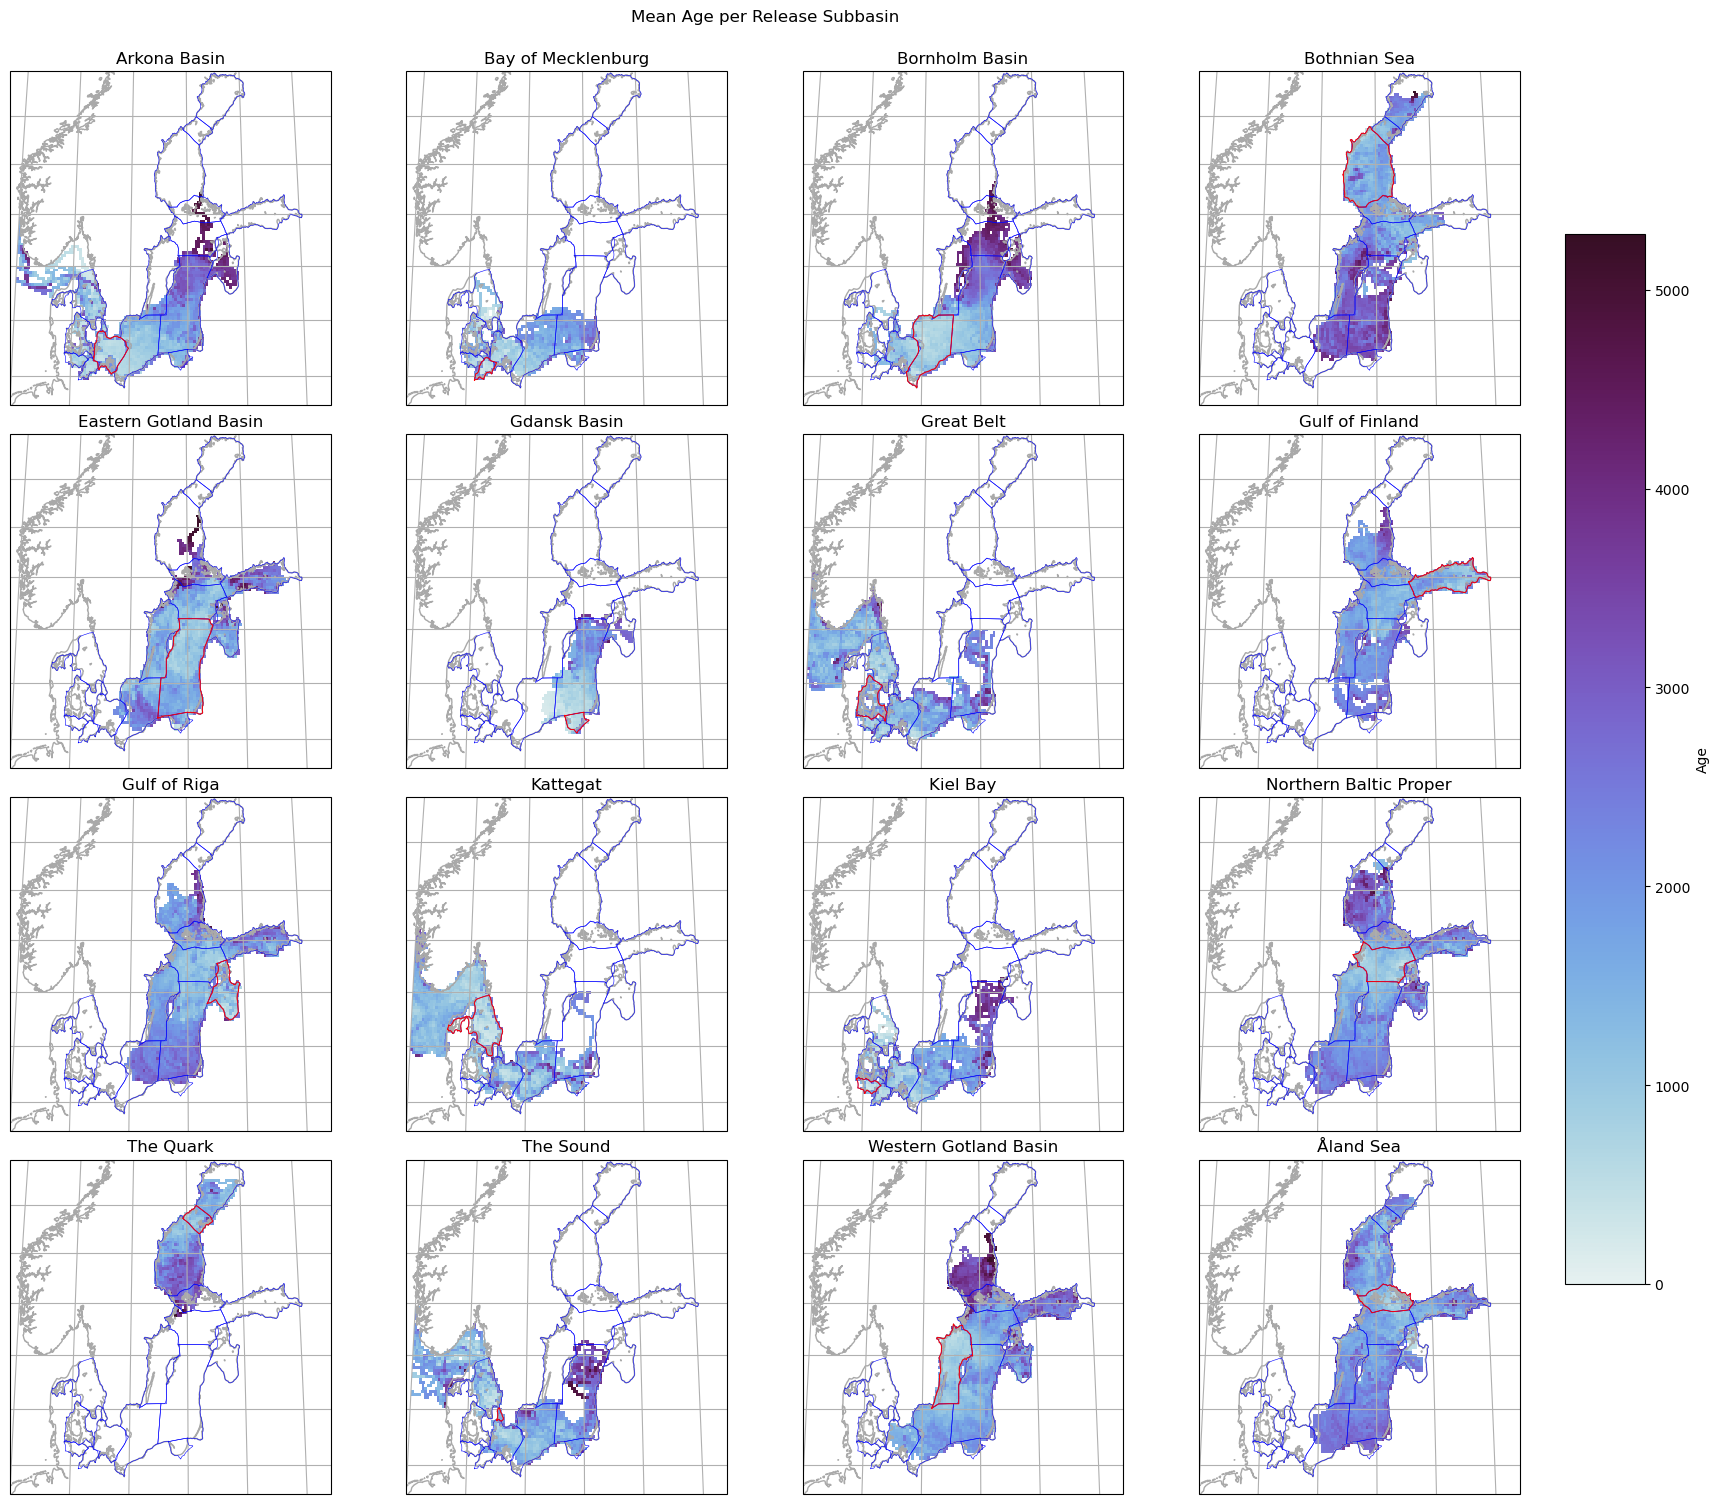

In [130]:
vmin = 0
vmax = 220*24
fig, axes = plt.subplots(
        figsize=(16, 15),
        nrows=4, ncols=4, 
        sharex=True, sharey=True, 
        subplot_kw=dict(projection=ccrs.EckertIV(central_longitude=central_longitude,)), 
)

fig.suptitle("Mean Age per Release Subbasin", y=1)
for ax, basin in zip(axes.flatten(), ds_plot_1.subbasin.values):
        subbasins_simple.plot(ax=ax, transform=ccrs.Geodetic(), color="b", lw=.4, zorder=10,)
        ax.plot(*subbasins_simple.loc[basin].xy, transform=ccrs.PlateCarree(), color="r", lw=.7, zorder=30,)
        im = ds_plot_1.sel(subbasin=basin).plot.pcolormesh(
                x="lon", y="lat", ax=ax, 
                cmap=cmocean.cm.dense,
                vmin=vmin, vmax=vmax, 
                add_colorbar=False, transform=ccrs.PlateCarree(),
        )
        ax.set_title(basin)
        ax.coastlines(color="darkgrey")
        ax.gridlines(draw_labels=False)
        ax.set_extent((lon_min, lon_max, lat_min, lat_max))

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([1., 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax, label="Age")
fig.tight_layout()
plt.show()

# Regional SH Plots

## Animations

In [204]:
import matplotlib.animation as animation

In [254]:
ds_ani = np.log10(ds_plot_0.isel(z=0)).groupby_bins(group="obs", bins=220).mean(dim="obs").rename(dict(obs_bins="obs"))

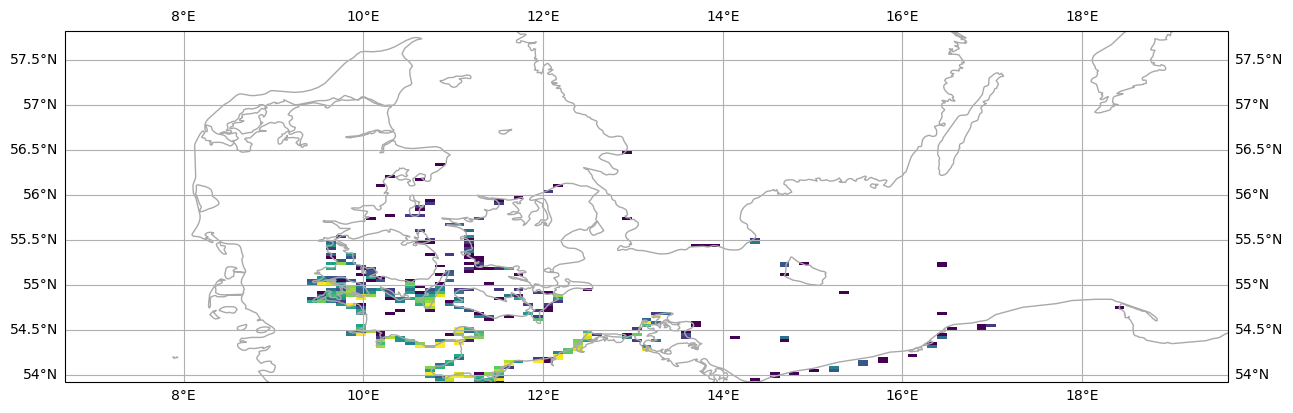

In [255]:
vmin, vmax = list(ds_ani.where(ds_ani.notnull() & ~np.isinf(ds_ani)).quantile([0.05, 0.95]))

fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(
                projection=ccrs.PlateCarree()
                ), 
)
heat = ax.pcolormesh(
        ds_ani.lon, ds_ani.lat,
        ds_ani.isel(obs=0).T,
        vmin=vmin, vmax=vmax, 
        transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_ani.lon.min(), ds_ani.lon.max(), ds_ani.lat.min(), ds_ani.lat.max()))
def animate(i):
        heat.set_array(ds_ani.isel(obs=i).values.T.flatten())

ani = animation.FuncAnimation(
        fig, animate, 
        interval=100, frames=len(ds_ani.obs)
)
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_heatmap.gif", 
        writer="pillow")
plt.show()

In [263]:
ds_scatter_ani = ds_SH_0.groupby_bins(group="obs", bins=22).mean(dim="obs").rename(dict(obs_bins="obs")).isel(trajectory=slice(50))

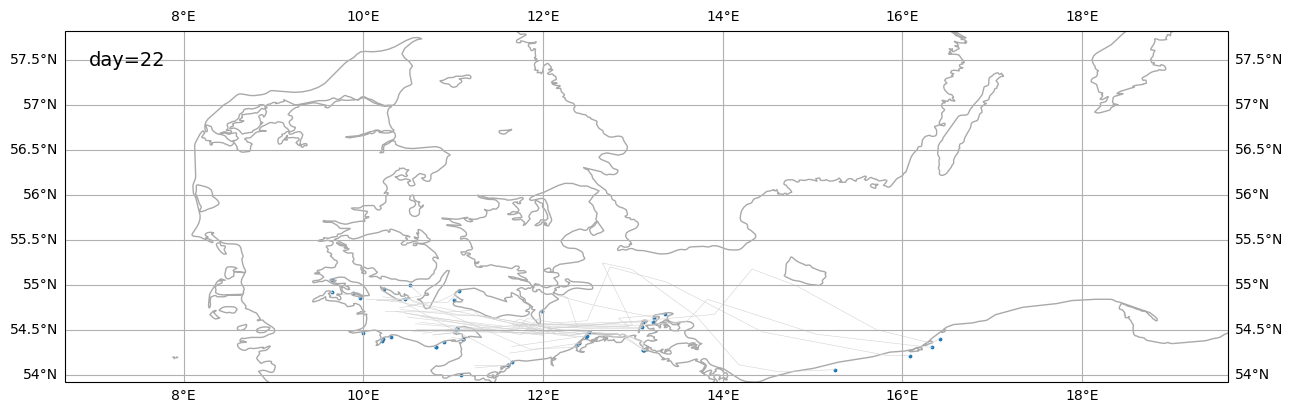

In [ ]:
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(
                # projection=ccrs.EckertIV(central_longitude=central_longitude,)
                projection=ccrs.PlateCarree()
                ), 
)

x_initial = ds_scatter_ani.lon.T
y_initial = ds_scatter_ani.lat.T
scat = ax.scatter(
        ds_scatter_ani.isel(obs=0).lon.T,
        ds_scatter_ani.isel(obs=0).lat.T,
        s=3, transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_ani.lon.min(), ds_ani.lon.max(), ds_ani.lat.min(), ds_ani.lat.max()))
time_text = ax.text(0.02,0.9,"day=1", transform=ax.transAxes, size=14,)

def animate(frame):
        time_text.set_text(f"day={(int(frame+1))}")
        x = ds_scatter_ani.isel(obs=frame).lon.values
        y = ds_scatter_ani.isel(obs=frame).lat.values
        data = np.stack([x,y]).T
        scat.set_offsets(data)
        # for i, line in enumerate(lines):
        #         x_update = x_initial[i][:frame+1]
        #         y_update = y_initial[i][:frame+1]
        #         line.set_xdata(x_update)
        #         line.set_ydata(y_update)
        # return lines

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_ani.obs))
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter.gif", 
        writer="pillow")
plt.show()

In [ ]:
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(
                # projection=ccrs.EckertIV(central_longitude=central_longitude,)
                projection=ccrs.PlateCarree()
                ), 
)

x_initial = ds_scatter_ani.lon.T
y_initial = ds_scatter_ani.lat.T

lines = [ax.plot(x, y, color="lightgrey", linewidth=.4)[0] for x, y in zip(x_initial, y_initial)]

scat = ax.scatter(
        ds_scatter_ani.isel(obs=0).lon.T,
        ds_scatter_ani.isel(obs=0).lat.T,
        s=3, transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_ani.lon.min(), ds_ani.lon.max(), ds_ani.lat.min(), ds_ani.lat.max()))
time_text = ax.text(0.02,0.9,"day=1", transform=ax.transAxes, size=14,)

def animate(frame):
        time_text.set_text(f"day={(int(frame+1))}")
        x = ds_scatter_ani.isel(obs=frame).lon.values
        y = ds_scatter_ani.isel(obs=frame).lat.values
        data = np.stack([x,y]).T
        scat.set_offsets(data)
        for i, line in enumerate(lines):
                x_update = x_initial[i][:frame+1]
                y_update = y_initial[i][:frame+1]
                line.set_xdata(x_update)
                line.set_ydata(y_update)
        return lines

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_ani.obs))
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter_lines.gif", 
        writer="pillow")
plt.show()

KeyboardInterrupt: 

Error in callback <function flush_figures at 0x1465e7635b20> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [225]:
ds_scatter_SH_ani = ds_SH.groupby_bins(group="obs", bins=220).mean(dim="obs").isel(trajectory=slice(50))
ds_scatter_SH_ani

<xarray.Dataset> Size: 1MB
Dimensions:              (obs_bins: 220, trajectory: 50)
Coordinates:
  * trajectory           (trajectory) int64 400B 1 38 58 89 ... 1887 1915 1916
  * obs_bins             (obs_bins) object 2kB (-5.303, 24.105] ... (5278.895...
Data variables: (12/14)
    age_sec              (obs_bins, trajectory) float32 44kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    cell_ID              (obs_bins, trajectory) float64 88kB 5.103e+04 ... 5....
    lat                  (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    lon                  (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    z                    (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    distance             (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    ...                   ...
    valid_obs_count      (obs_bins, trajectory) float64 88kB dask.array<chunksize=(1, 50), meta=np.ndarray>
    lat_diff             (obs_bins, trajectory) float64 88kB 0.07922 ... 0.9842
    lon_diff             (obs_bins, trajectory) float64 88kB 0.07524 ... 2.592
    cell_code            (obs_bins, trajectory) object 88kB '10kmE438N347' .....
    age_sec_obs          (obs_bins, trajectory) float32 44kB 4.41e+04 ... 1.9...
    subbasin             (obs_bins, trajectory) object 88kB 'Kiel Bay' ... 'K...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        NewParticleAdvectionRK4_2D_SIGMABSHaging_kernel
    parcels_mesh:           spherical
    parcels_version:        3.0.6

In [ ]:
fig, ax = plt.subplots(
        figsize=(15,15),
        subplot_kw=dict(
                projection=ccrs.PlateCarree()
                ), 
)

x_initial = ds_scatter_SH_ani.lon.T
y_initial = ds_scatter_SH_ani.lat.T

# lines = [ax.plot(x, y, color="lightgrey", linewidth=.4)[0] for x, y in zip(x_initial, y_initial)]

scat = ax.scatter(
        ds_scatter_SH_ani.isel(obs_bins=0).lon.T,
        ds_scatter_SH_ani.isel(obs_bins=0).lat.T,
        s=3, transform=ccrs.PlateCarree(),
)
ax.coastlines(color="darkgrey")
ax.gridlines(draw_labels=True)
ax.set_extent((ds_scatter_SH_ani.lon.min(), ds_scatter_SH_ani.lon.max(), ds_scatter_SH_ani.lat.min(), ds_scatter_SH_ani.lat.max()))
time_text = ax.text(0.02,0.9,"day=1", transform=ax.transAxes, size=14,)

def animate(frame):
        time_text.set_text(f"day={(int(frame+1))}")
        x = ds_scatter_SH_ani.isel(obs_bins=frame).lon.values
        y = ds_scatter_SH_ani.isel(obs_bins=frame).lat.values
        data = np.stack([x,y]).T
        scat.set_offsets(data)
        # for i, line in enumerate(lines):
        #         x_update = x_initial[i][:frame+1]
        #         y_update = y_initial[i][:frame+1]
        #         line.set_xdata(x_update)
        #         line.set_ydata(y_update)
        # return lines

ani = animation.FuncAnimation(fig, func=animate, interval=100, frames=len(ds_scatter_SH_ani.obs_bins))
ani.save(
        filename="/gxfs_work/geomar/smomw597/2025_Fucus/2025_fucus-dispersal/output/SH_scatter.gif", 
        writer="pillow")
plt.show()

In [ ]:
# gdf_release_area.filter(
# gdf_release_area.loc[
gdf_release_area.to_crs(crs=ccrs.Geodetic()).within(
        sh_border.to_crs(crs=ccrs.Geodetic())
).max()
# ]
# )


False

In [ ]:
split_line_by_point(sh_border.boundary.clip(gdf_baltic_buffed).explode()[1])

In [ ]:
gdf_baltic = gdf_subbasins_area.dissolve()
coast_region_radius_km = 25
coast_region_radius = coast_region_radius_km / earth_radius * radians_to_degrees
coast_region_radius
gdf_baltic_simple = gdf_baltic.buffer(.2).buffer(-.2)
gdf_baltic_benthic = gdf_baltic_simple.buffer(-coast_region_radius)
gdf_baltic_buffed = gdf_baltic.buffer(.2)
gdf_baltic_coast = gdf_baltic_buffed.difference(gdf_baltic_benthic)
# gdf_baltic_coast

In [80]:
gdf_baltic_buffed.difference(gdf_baltic).buffer(.2).plot()

KeyboardInterrupt: 

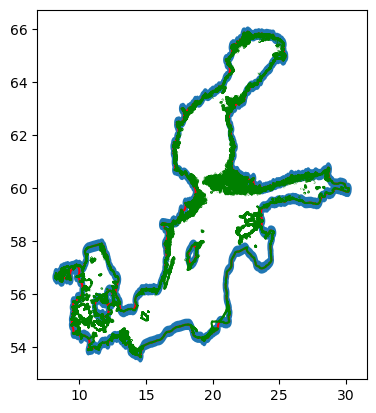

In [78]:
fig, ax = plt.subplots()
gdf_baltic_coast.plot(ax=ax)
gdf_baltic_simple.boundary.plot(ax=ax, color="r")
gdf_baltic.boundary.plot(ax=ax, color="g")
plt.show()

<Axes: >

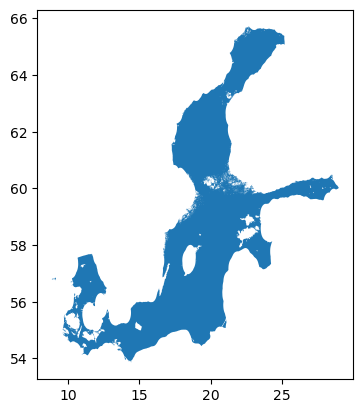

In [ ]:
(gdf_baltic.clip(gdf_baltic_benthic)).plot()

<Axes: >

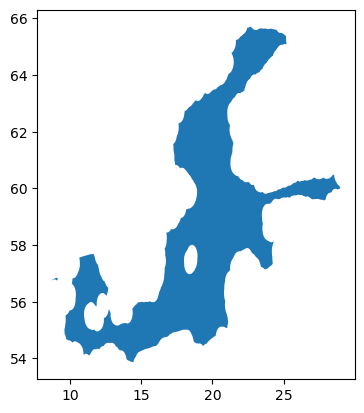

In [34]:
gdf_baltic_benthic.plot()

statistics of in which month and from which starting position do the particles travel how far, and the area

In [45]:
def calc_dist_quantiles(ds):
        dist = 111e3 * (
                ((ds[["lon", "lat"]] - ds.isel(obs=0, drop=True)[["lon", "lat"]]) ** 2).to_array() 
                * xr.DataArray([np.cos(np.deg2rad(60)),1], dims="variable")
        ).sum(dim="variable")**0.5
        return dist.where(ds.lon.notnull()).quantile(np.linspace(0,1,5), dim="trajectory").rename("dist")

In [47]:
df_distance_q = ds_trajectories.groupby("subbasin").apply(calc_dist_quantiles).compute().to_dataframe()

In [ ]:
# df_distance_q.unstack(0).loc[0.5].assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").max()["dist"].plot()


In [48]:
df_distance_m = ds_trajectories.groupby("subbasin").apply(calc_dist_mean).compute().to_dataframe()
df_distance_m = df_distance_m.unstack(0).assign(time=np.timedelta64(1, "h")*np.arange(5304)).set_index("time", drop=True).resample("5D").mean()["dist"]

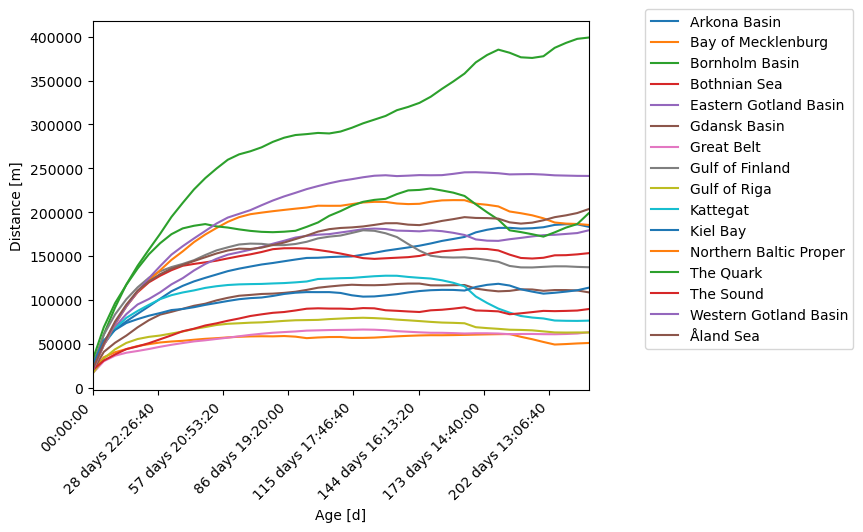

In [128]:
# fig, ax = plt.subplots(111, figsize=(15,10))
p = df_distance_m.plot()
p.legend(loc="best", bbox_to_anchor=(1.1, 1.05))
# p.tick_params("x", rotation=45,)
plt.xticks(rotation=45, ha="right")
# a =print(p.xaxis.get_ticklabels())
# print(p.xaxis.get_majorticklocs())
# p.xaxis.set_major_formatter()
# p.set_xticklabels(labels=np.timedelta64(1, "D")*np.arange(0, 220, 7))
p.set_xlabel("Age [d]")
p.set_ylabel("Distance [m]")
plt.show()

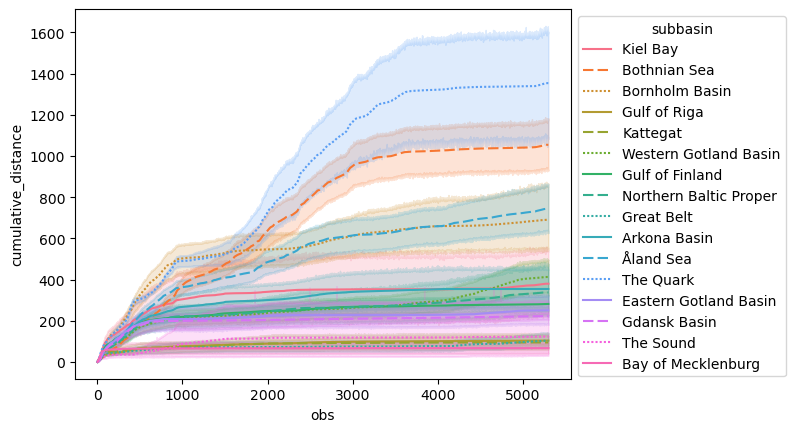

In [ ]:
fig = plt.Figure((15,15))
ax = sns.lineplot(
        data=df, 
        x="obs", y="cumulative_distance",
        hue="subbasin",
        style="subbasin",
        dashes=['', (5, 2), (1, 1)],
)
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

<Axes: xlabel='total_distance', ylabel='subbasin'>

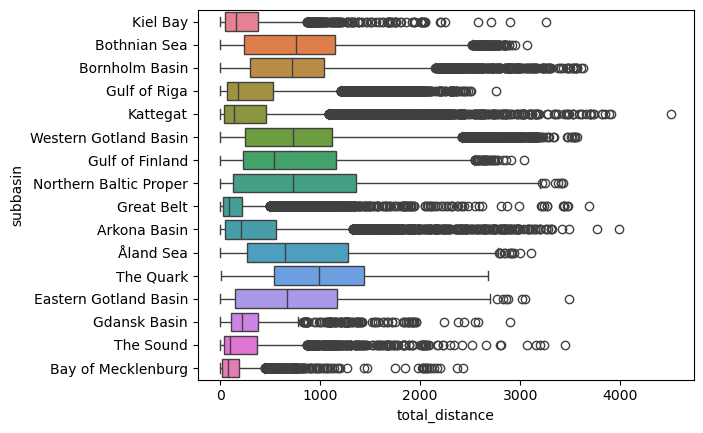

In [103]:
sns.boxplot(df_total, x="total_distance", y="subbasin", hue="subbasin")

In [59]:
basin_names = pd.Index(data=list(subbasin_grouped.groups.keys()), name="subbasins")
basin_idx = pd.Index(data=["trajs", "cells"], name="index")

In [60]:
basins = pd.DataFrame(
        index=basin_names,
        columns=basin_idx,
        data=basin_counts,
)

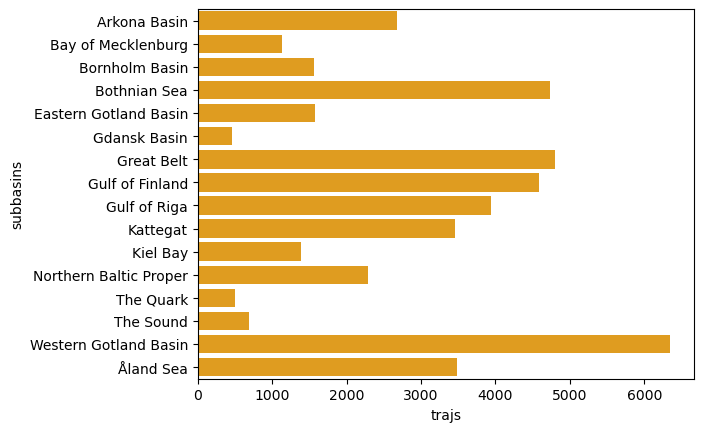

<Axes: xlabel='cells', ylabel='subbasins'>

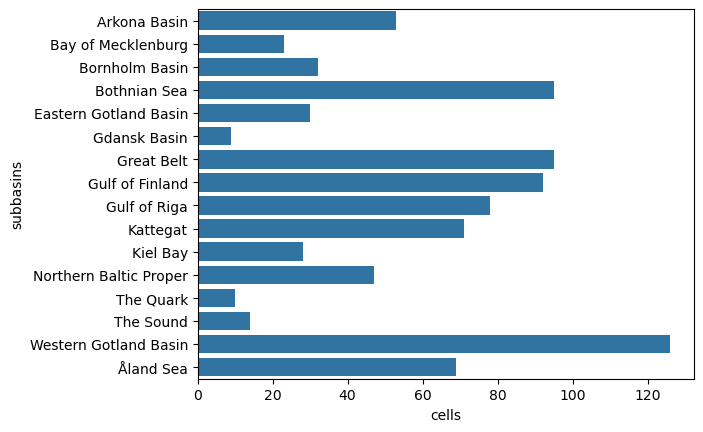

In [61]:
sns.barplot(basins, x="trajs", y="subbasins", color="orange")
plt.show()
sns.barplot(basins, x="cells", y="subbasins")

In [ ]:
mean_total_distance_per_cell = ds_trajectories.total_distance.groupby("cell_code").mean()
mean_total_distance_per_cell

In [ ]:
# open depth files and define depth cmap
path_static_files = Path("/gxfs_work/geomar/smomw122/bsh_operationalmodel_data")
path_static_fine = path_static_files / "static_file_fine"
path_static_coarse = path_static_files / "static_file_coarse"
depth_coarse = xr.open_dataset(path_static_coarse / "H0_file_coarse.nc").H0
depth_fine = xr.open_dataset(path_static_fine / "H0_file_fine.nc").H0
cm_deep = cmocean.cm.deep

In [ ]:
traj_lat = np.concatenate(traj_moving.lat.values)
traj_lon = np.concatenate(traj_moving.lon.values)

traj_lat = traj_lat[np.invert(np.isnan(traj_lat,))]
traj_lon = traj_lon[np.invert(np.isnan(traj_lon,))]